In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

df = iris.frame.copy()

print(df.head())
print(df.shape)
print(df.info())
print(df['target'].value_counts())
print(iris.target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
(150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64

In [47]:
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [48]:
df['species'] = df['target'].map({0: 'setosa', 1: 'vercicolor', 2: 'virginica'})

print(df[['species', 'target']])

       species  target
0       setosa       0
1       setosa       0
2       setosa       0
3       setosa       0
4       setosa       0
..         ...     ...
145  virginica       2
146  virginica       2
147  virginica       2
148  virginica       2
149  virginica       2

[150 rows x 2 columns]


In [49]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


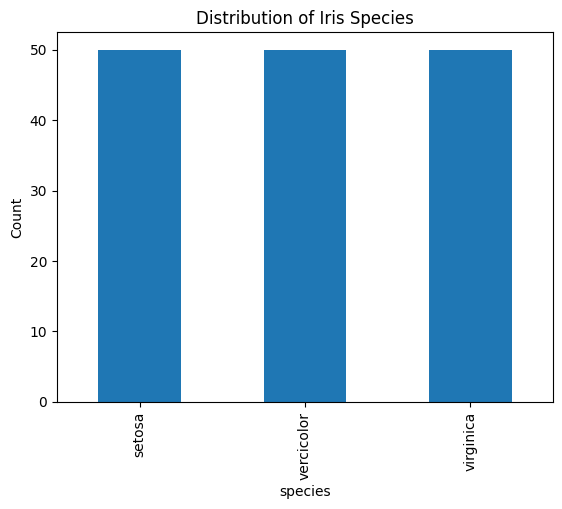

In [56]:
df['species'].value_counts().plot(kind='bar')
plt.title("Distribution of Iris Species")
plt.xlabel("species")
plt.ylabel("Count")
plt.show()

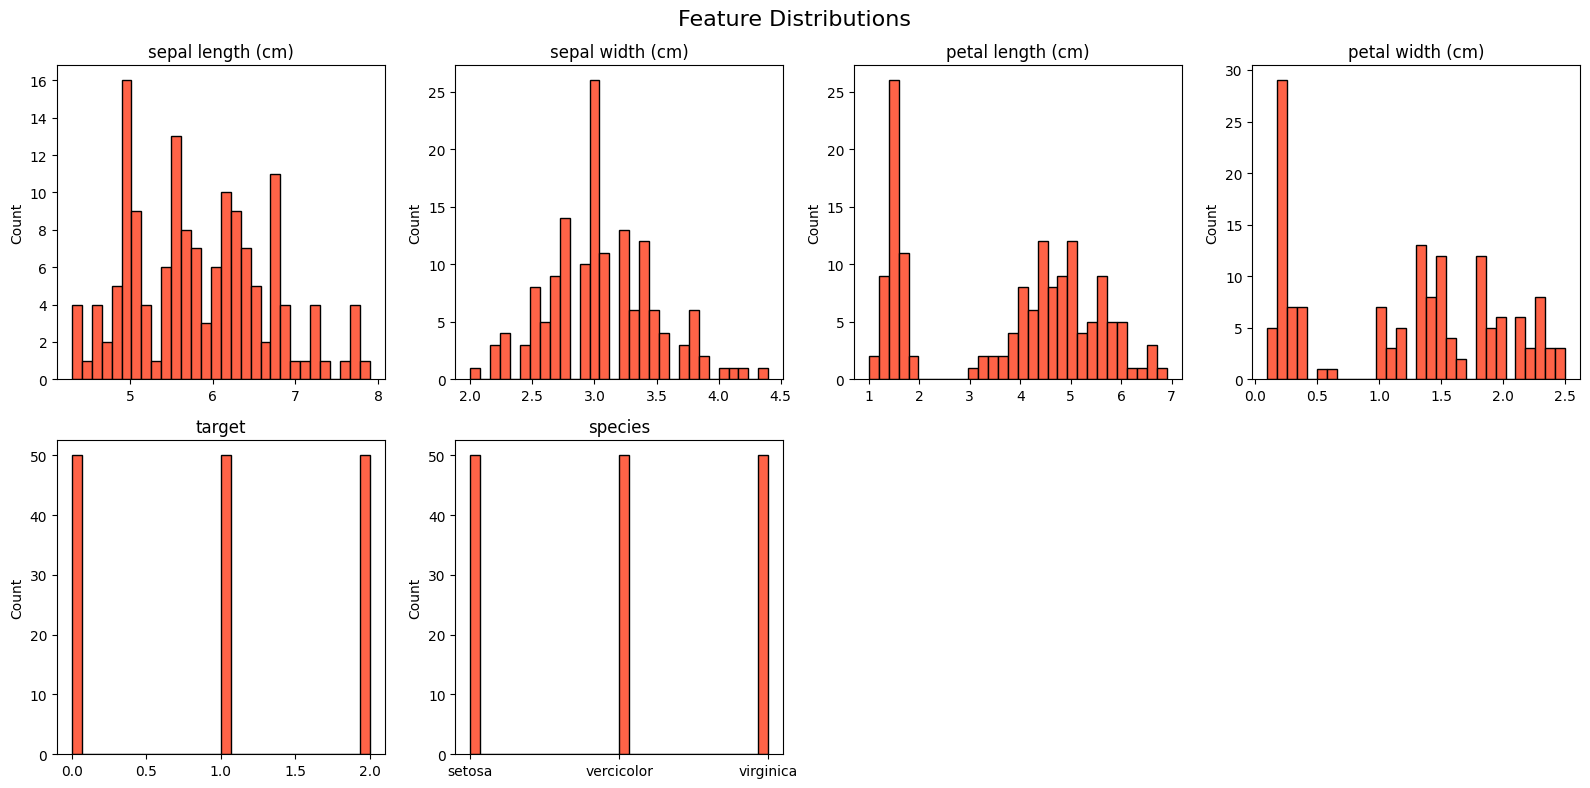

In [54]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col].dropna(), bins=30, color="tomato", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

for ax in axes[len(df.columns):]:
    ax.set_visible(False)

fig.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

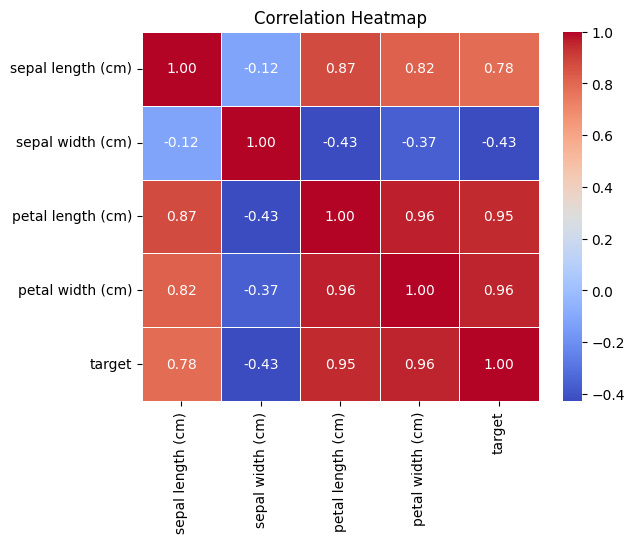

In [63]:
plt.Figure(figsize=(10, 8))
corr = df.drop(columns=['species']).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


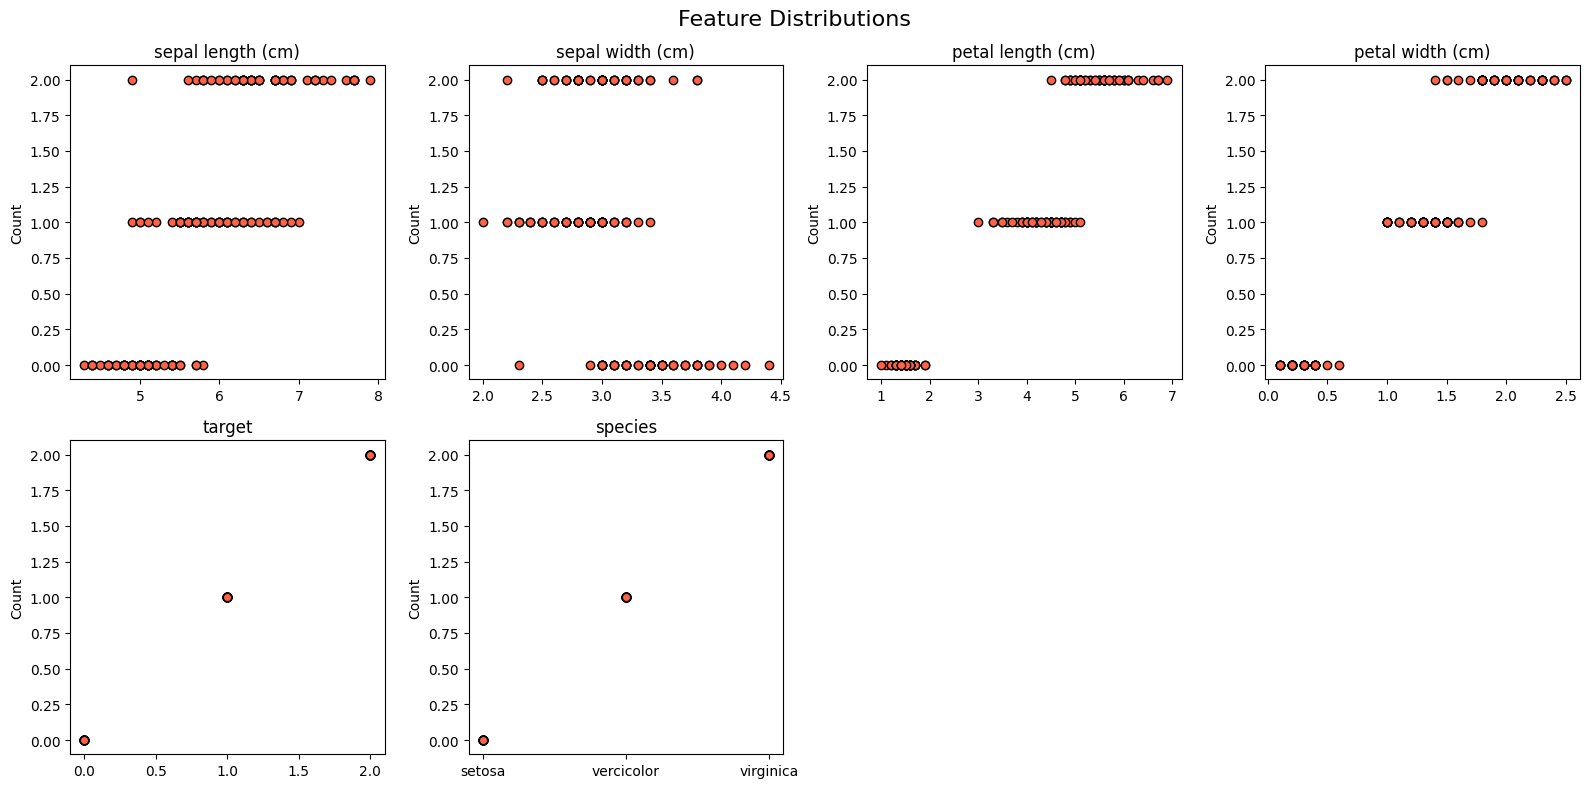

In [64]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].scatter(df[col], df['target'], color="tomato", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

for ax in axes[len(df.columns):]:
    ax.set_visible(False)

fig.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [65]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target', 'species'])
Y = df['target']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=12)

print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

(120, 4) (120,)
(30, 4) (30,)


In [74]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=200))
])

pipeline.fit(X_train, Y_train)
Y_pred_log = pipeline.predict(X_test)


Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      0.89      0.94         9
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



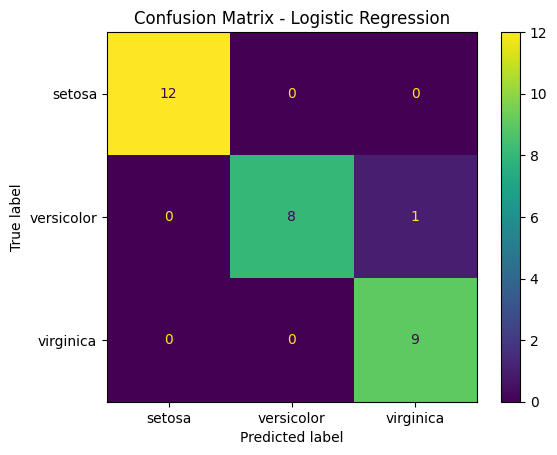

In [75]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

print("Accuracy:", accuracy_score(Y_test, Y_pred_log))
print(classification_report(Y_test, Y_pred_log, target_names=iris.target_names))

ConfusionMatrixDisplay.from_predictions(
    Y_test, Y_pred_log,
    display_labels=iris.target_names
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      0.78      0.88         9
   virginica       0.82      1.00      0.90         9

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.92        30
weighted avg       0.95      0.93      0.93        30



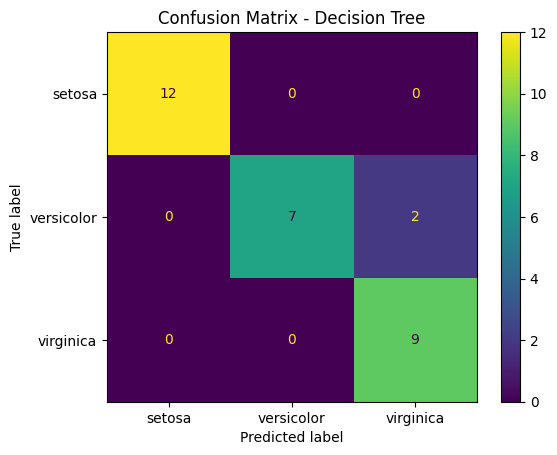

In [76]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, Y_train)
y_pred_tree = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, y_pred_tree))
print(classification_report(Y_test, y_pred_tree, target_names=iris.target_names))

ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred_tree,
    display_labels=iris.target_names
)
plt.title("Confusion Matrix - Decision Tree")
plt.show()